# Météo et végétation — site_004

Ce notebook cherche à comprendre quelles conditions météo précèdent les variations de la végétation. L’analyse est centrée sur le NDMI calculé avec un retrait de 10 m. NDVI, EVI et NDRE interviennent seulement dans une comparaison secondaire.

Il s’agit d’une analyse exploratoire : une association statistique ne démontre pas une causalité. ERA5 Seamless décrit une météo régionale modélisée et ne mesure ni l’irrigation réelle, ni les pratiques culturales, ni l’hétérogénéité du sol dans la parcelle.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "data" / "processed").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Impossible de trouver la racine du projet."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
SITE_ID = "site_004"

MERGED_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / f"vegetation_weather_{SITE_ID}.csv"
)

DAILY_WEATHER_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / f"weather_daily_{SITE_ID}.csv"
)

for input_file in [MERGED_FILE, DAILY_WEATHER_FILE]:
    if not input_file.is_file():
        raise FileNotFoundError(f"CSV introuvable : {input_file}")

df_weather = (
    pd.read_csv(
        MERGED_FILE,
        parse_dates=["acquisition_date", "date"],
        low_memory=False,
    )
    .sort_values("acquisition_date")
    .reset_index(drop=True)
)

df_daily = (
    pd.read_csv(
        DAILY_WEATHER_FILE,
        parse_dates=["date"],
        low_memory=False,
    )
    .sort_values("date")
    .reset_index(drop=True)
)

print("Fichier fusionné :", MERGED_FILE)
print("Dimensions :", df_weather.shape)
print(
    "Période Sentinel :",
    df_weather["acquisition_date"].min().date(),
    "->",
    df_weather["acquisition_date"].max().date(),
)
print()
print("Fichier météo quotidien :", DAILY_WEATHER_FILE)
print("Dimensions :", df_daily.shape)
print(
    "Période météo :",
    df_daily["date"].min().date(),
    "->",
    df_daily["date"].max().date(),
)

Fichier fusionné : D:\Compte ASUS\Desktop\Eve\data\processed\vegetation_weather_site_004.csv
Dimensions : (1479, 170)
Période Sentinel : 2015-07-30 -> 2026-06-17

Fichier météo quotidien : D:\Compte ASUS\Desktop\Eve\data\processed\weather_daily_site_004.csv
Dimensions : (4005, 54)
Période météo : 2015-07-01 -> 2026-06-17


## 1. Qualité et cohérence des données

Cette section vérifie le modèle météo, les identifiants, les dates, la complétude des variables et la cohérence mathématique des indicateurs dérivés. Une valeur météo inconnue reste manquante : elle n’est jamais remplacée par zéro.

In [3]:
QUALITY_WEATHER_COLUMNS = [
    "precipitation_sum",
    "et0_fao_evapotranspiration",
    "shortwave_radiation_sum",
    "wind_speed_10m_mean",
    "vapour_pressure_deficit_max",
    "soil_moisture_0_to_7cm_mean",
    "soil_moisture_7_to_28cm_mean",
    "precipitation_30d",
    "et0_30d",
    "water_balance_30d",
    "vpd_max_30d",
    "dryness_index_30d",
]

REQUIRED_COLUMNS = {
    "site_id",
    "site_id_weather",
    "acquisition_date",
    "date",
    "weather_model",
    "usable_all_indices",
    "ndmi_is_usable",
    "ndmi_buffer_10m_is_usable",
    "ndvi_mean",
    "evi_mean",
    "ndmi_mean",
    "ndmi_buffer_10m_mean",
    "ndre_mean",
    *QUALITY_WEATHER_COLUMNS,
}

missing_columns = sorted(REQUIRED_COLUMNS - set(df_weather.columns))

if missing_columns:
    raise KeyError(
        "Colonnes obligatoires absentes : "
        f"{missing_columns}"
    )

if df_weather[["acquisition_date", "date"]].isna().any().any():
    raise ValueError("Certaines dates fusionnées sont invalides.")

if df_daily["date"].isna().any():
    raise ValueError("Certaines dates météo sont invalides.")

if df_weather["acquisition_date"].duplicated().any():
    raise ValueError("Des dates Sentinel sont dupliquées.")

if df_daily["date"].duplicated().any():
    raise ValueError("Des dates météo quotidiennes sont dupliquées.")

if not df_weather["acquisition_date"].equals(df_weather["date"]):
    raise ValueError("acquisition_date et date ne correspondent pas.")

if not df_weather["site_id"].equals(df_weather["site_id_weather"]):
    raise ValueError("Les identifiants végétation et météo diffèrent.")

merged_models = set(df_weather["weather_model"].dropna().unique())
daily_models = set(df_daily["weather_model"].dropna().unique())

if merged_models != {"era5_seamless"}:
    raise ValueError(f"Modèle fusionné inattendu : {merged_models}")

if daily_models != {"era5_seamless"}:
    raise ValueError(f"Modèle quotidien inattendu : {daily_models}")

balance_error = (
    df_weather["water_balance_30d"]
    - (
        df_weather["precipitation_30d"]
        - df_weather["et0_30d"]
    )
).abs().max()

dryness_error = (
    df_weather["dryness_index_30d"]
    + df_weather["water_balance_30d"]
).abs().max()

if balance_error > 1e-9 or dryness_error > 1e-9:
    raise ValueError("Les indicateurs hydriques sont incohérents.")

quality_table = pd.DataFrame(
    {
        "non_null": df_weather[QUALITY_WEATHER_COLUMNS].notna().sum(),
        "missing": df_weather[QUALITY_WEATHER_COLUMNS].isna().sum(),
        "coverage_ratio": df_weather[QUALITY_WEATHER_COLUMNS].notna().mean(),
        "minimum": df_weather[QUALITY_WEATHER_COLUMNS].min(),
        "median": df_weather[QUALITY_WEATHER_COLUMNS].median(),
        "maximum": df_weather[QUALITY_WEATHER_COLUMNS].max(),
    }
).sort_values("coverage_ratio")

minimum_coverage = 0.99
insufficient_coverage = quality_table.loc[
    quality_table["coverage_ratio"] < minimum_coverage
]

if not insufficient_coverage.empty:
    raise ValueError(
        "Couverture météo inférieure à 99 % : "
        f"{insufficient_coverage.index.tolist()}"
    )

incomplete_weather_dates = df_weather.loc[
    df_weather[QUALITY_WEATHER_COLUMNS].isna().any(axis=1),
    ["acquisition_date", *QUALITY_WEATHER_COLUMNS],
]

print("Modèle météo : era5_seamless")
print("Dates et sites : cohérents")
print("Doublons : aucun")
print(f"Erreur maximale du bilan hydrique : {balance_error:.3g}")
print(f"Erreur maximale de l'indice de sécheresse : {dryness_error:.3g}")
display(quality_table.round(3))
print("Dates Sentinel avec météo incomplète :")
display(incomplete_weather_dates)

Modèle météo : era5_seamless
Dates et sites : cohérents
Doublons : aucun
Erreur maximale du bilan hydrique : 5.68e-14
Erreur maximale de l'indice de sécheresse : 0


,non_null,missing,coverage_ratio,minimum,median,maximum
precipitation_sum,1478,1,0.999,0.000,0.100,50.200
et0_fao_evapotranspiration,1478,1,0.999,0.190,2.320,7.830
shortwave_radiation_sum,1478,1,0.999,0.500,13.785,30.020
wind_speed_10m_mean,1478,1,0.999,1.400,8.700,30.200
vapour_pressure_deficit_max,1478,1,0.999,0.060,0.830,5.290
soil_moisture_0_to_7cm_mean,1478,1,0.999,0.130,0.346,0.431
soil_moisture_7_to_28cm_mean,1478,1,0.999,0.155,0.343,0.432
precipitation_30d,1478,1,0.999,2.600,76.250,244.300
et0_30d,1478,1,0.999,14.140,74.800,196.630
water_balance_30d,1478,1,0.999,-181.630,7.205,208.020


Dates Sentinel avec météo incomplète :


,acquisition_date,precipitation_sum,et0_fao_evapotranspiration,shortwave_radiation_sum,wind_speed_10m_mean,vapour_pressure_deficit_max,soil_moisture_0_to_7cm_mean,soil_moisture_7_to_28cm_mean,precipitation_30d,et0_30d,water_balance_30d,vpd_max_30d,dryness_index_30d
1478,2026-06-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Populations d’analyse

L’échantillon principal exige un NDMI bufferisé à 10 m utilisable et des variables météo complètes. Le masque des quatre indices est conservé uniquement pour la comparaison secondaire. Cette séparation évite de perdre des dates NDMI parce qu’un autre indice est invalide.

In [4]:
WEATHER_FEATURES = [
    "precipitation_7d",
    "precipitation_14d",
    "precipitation_30d",
    "et0_7d",
    "et0_14d",
    "et0_30d",
    "water_balance_7d",
    "water_balance_14d",
    "water_balance_30d",
    "temperature_mean_7d",
    "temperature_mean_14d",
    "temperature_mean_30d",
    "temperature_max_7d",
    "temperature_max_14d",
    "temperature_max_30d",
    "vpd_max_7d",
    "vpd_max_14d",
    "vpd_max_30d",
    "soil_moisture_0_7cm_mean_7d",
    "soil_moisture_0_7cm_mean_14d",
    "soil_moisture_0_7cm_mean_30d",
    "soil_moisture_7_28cm_mean_7d",
    "soil_moisture_7_28cm_mean_14d",
    "soil_moisture_7_28cm_mean_30d",
    "radiation_sum_7d",
    "radiation_sum_14d",
    "radiation_sum_30d",
]

TARGET_COLUMN = "ndmi_buffer_10m_mean"

weather_complete_mask = df_weather[WEATHER_FEATURES].notna().all(axis=1)

primary_mask = (
    df_weather["ndmi_buffer_10m_is_usable"].fillna(False).astype(bool)
    & df_weather[TARGET_COLUMN].notna()
    & weather_complete_mask
)

analysis_df = df_weather.loc[primary_mask].copy()
analysis_df["month"] = analysis_df["acquisition_date"].dt.month
analysis_df["year"] = analysis_df["acquisition_date"].dt.year

growing_season = analysis_df.loc[
    analysis_df["month"].between(4, 10)
].copy()

all_indices_mask = (
    primary_mask
    & df_weather["usable_all_indices"].fillna(False).astype(bool)
)

all_indices_df = df_weather.loc[all_indices_mask].copy()

raw_buffer_common_mask = (
    primary_mask
    & df_weather["ndmi_is_usable"].fillna(False).astype(bool)
    & df_weather["ndmi_mean"].notna()
)

print("Toutes les lignes fusionnées :", len(df_weather))
print("NDMI buffer 10 m + météo :", len(analysis_df))
print("NDMI avril-octobre :", len(growing_season))
print("Quatre indices + météo :", len(all_indices_df))
print("NDMI brut et buffer sur dates communes :", int(raw_buffer_common_mask.sum()))

Toutes les lignes fusionnées : 1479
NDMI buffer 10 m + météo : 677
NDMI avril-octobre : 476
Quatre indices + météo : 676
NDMI brut et buffer sur dates communes : 676


## 3. Couverture temporelle

Le nombre d’images valides varie selon les années et les mois. Cette couverture doit être examinée avant toute comparaison interannuelle.

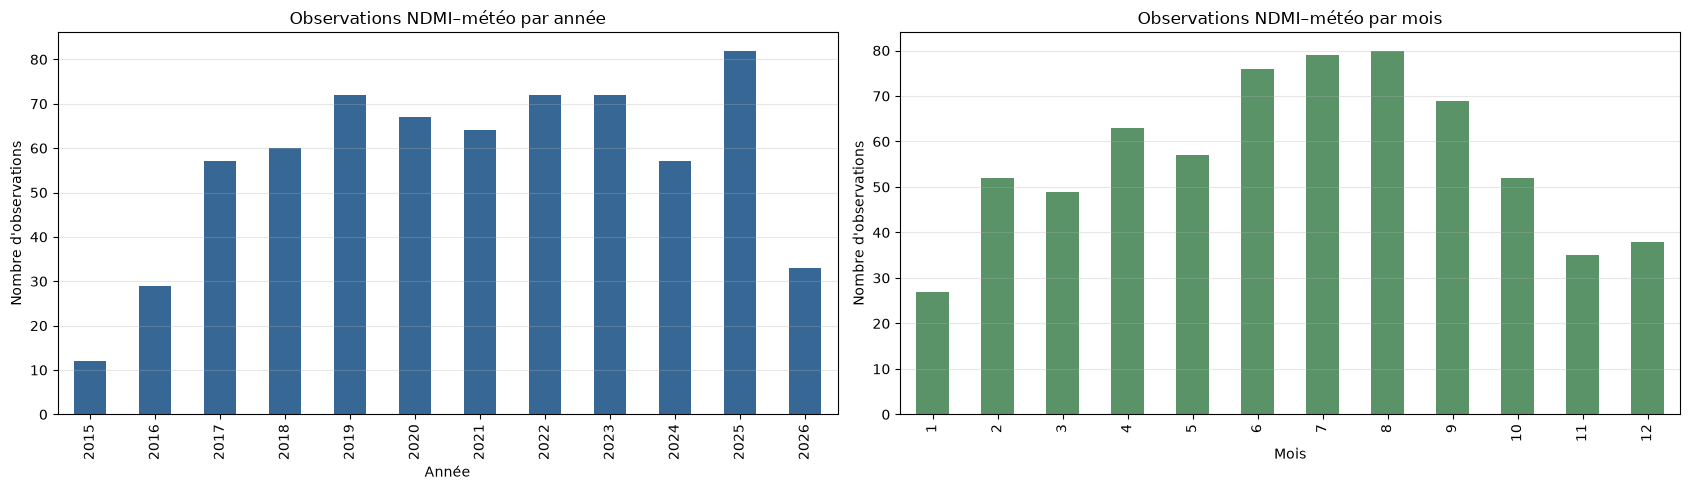

,observations
year,
2015,12
2016,29
2017,57
2018,60
2019,72
2020,67
2021,64
2022,72
2023,72


In [5]:
observations_by_year = (
    analysis_df.groupby("year").size().rename("observations")
)

observations_by_month = (
    analysis_df.groupby("month").size().reindex(range(1, 13), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

observations_by_year.plot(kind="bar", ax=axes[0], color="#376795")
axes[0].set_title("Observations NDMI–météo par année")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'observations")
axes[0].grid(axis="y", alpha=0.3)

observations_by_month.plot(kind="bar", ax=axes[1], color="#5A9367")
axes[1].set_title("Observations NDMI–météo par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Nombre d'observations")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

display(observations_by_year.to_frame())

## 4. NDMI et météo dans le temps

Les séries sont centrées et réduites pour comparer leur forme. Ces figures restent descriptives : le cycle saisonnier peut créer des ressemblances sans relation directe.

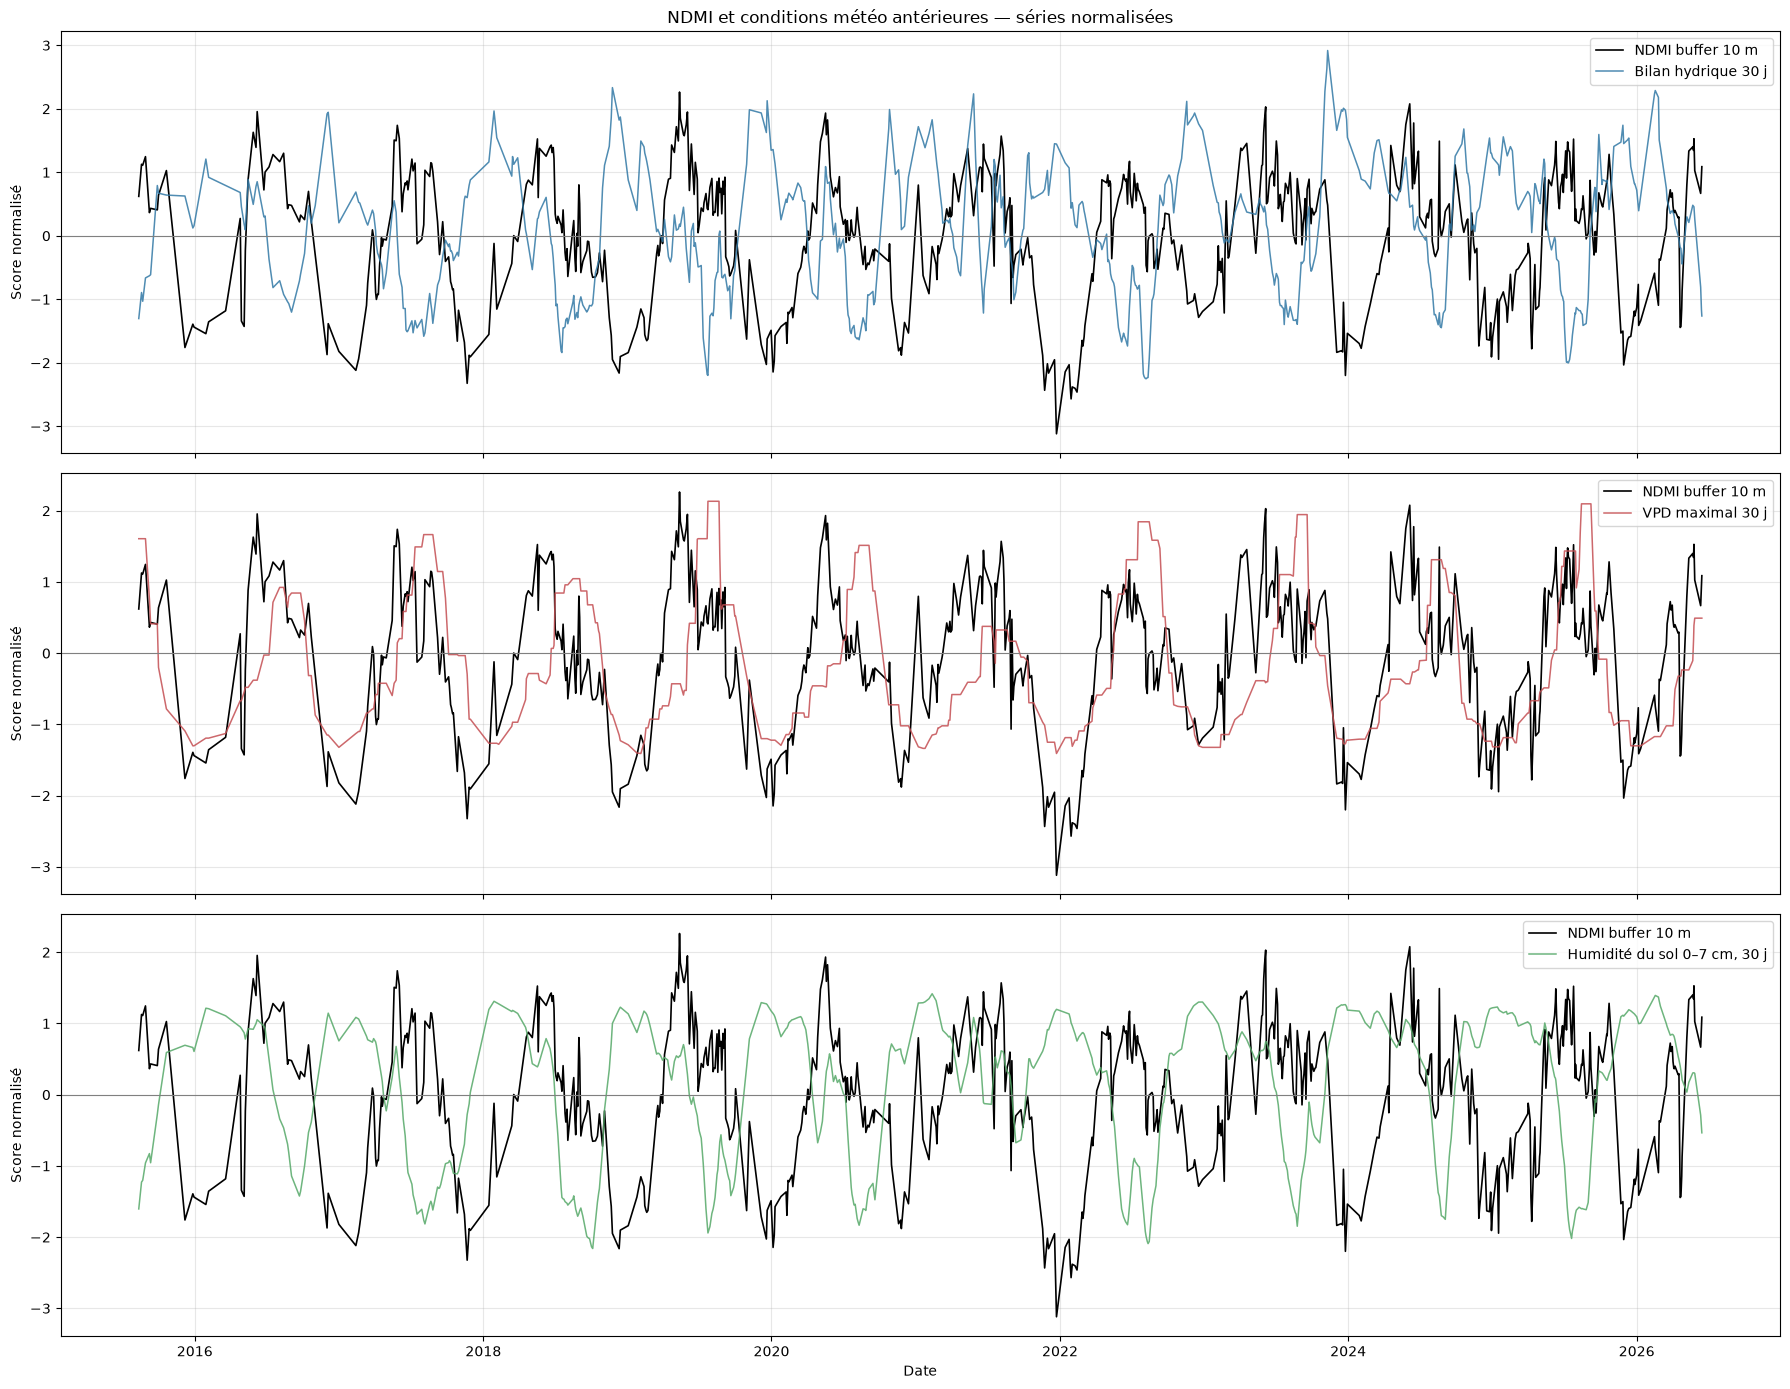

In [6]:
def zscore(series: pd.Series) -> pd.Series:
    standard_deviation = series.std()

    if pd.isna(standard_deviation) or standard_deviation == 0:
        return pd.Series(np.nan, index=series.index)

    return (series - series.mean()) / standard_deviation


plot_df = analysis_df.sort_values("acquisition_date").copy()
plot_df["ndmi_z"] = zscore(plot_df[TARGET_COLUMN])

series_to_compare = [
    ("water_balance_30d", "Bilan hydrique 30 j", "#3178A5"),
    ("vpd_max_30d", "VPD maximal 30 j", "#C44E52"),
    (
        "soil_moisture_0_7cm_mean_30d",
        "Humidité du sol 0–7 cm, 30 j",
        "#55A868",
    ),
]

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

for axis, (column, label, color) in zip(axes, series_to_compare):
    axis.plot(
        plot_df["acquisition_date"],
        plot_df["ndmi_z"],
        color="black",
        linewidth=1.2,
        label="NDMI buffer 10 m",
    )
    axis.plot(
        plot_df["acquisition_date"],
        zscore(plot_df[column]),
        color=color,
        linewidth=1.1,
        alpha=0.85,
        label=label,
    )
    axis.axhline(0, color="grey", linewidth=0.8)
    axis.set_ylabel("Score normalisé")
    axis.grid(alpha=0.3)
    axis.legend(loc="upper right")

axes[0].set_title("NDMI et conditions météo antérieures — séries normalisées")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

## 5. Associations brutes et saison de végétation

Pearson mesure surtout une relation linéaire. Spearman mesure une relation monotone et résiste mieux aux valeurs extrêmes. Les corrélations d’avril à octobre sont plus pertinentes agronomiquement, mais restent influencées par la saison.

In [7]:
def spearman_correlation(
    first: pd.Series,
    second: pd.Series,
) -> float:
    paired = pd.concat([first, second], axis=1).dropna()

    if len(paired) < 2:
        return np.nan

    first_rank = paired.iloc[:, 0].rank(method="average")
    second_rank = paired.iloc[:, 1].rank(method="average")

    return first_rank.corr(second_rank, method="pearson")


def correlation_table(
    dataframe: pd.DataFrame,
    target: str,
    features: list[str],
) -> pd.DataFrame:
    rows = []

    for feature in features:
        paired = dataframe[[target, feature]].dropna()

        rows.append(
            {
                "feature": feature,
                "n": len(paired),
                "pearson": paired[target].corr(paired[feature], method="pearson"),
                "spearman": spearman_correlation(
                    paired[target],
                    paired[feature],
                ),
            }
        )

    result = pd.DataFrame(rows).set_index("feature")
    result["abs_spearman"] = result["spearman"].abs()

    return result.sort_values("abs_spearman", ascending=False)


correlations_all_year = correlation_table(
    analysis_df,
    TARGET_COLUMN,
    WEATHER_FEATURES,
)

correlations_growing = correlation_table(
    growing_season,
    TARGET_COLUMN,
    WEATHER_FEATURES,
)

print("Toute l'année")
display(correlations_all_year.head(15).round(3))
print("Avril à octobre")
display(correlations_growing.head(15).round(3))

Toute l'année


,n,pearson,spearman,abs_spearman
feature,,,,
radiation_sum_14d,677,0.710,0.667,0.667
radiation_sum_30d,677,0.712,0.654,0.654
radiation_sum_7d,677,0.679,0.643,0.643
et0_14d,677,0.640,0.626,0.626
et0_7d,677,0.627,0.625,0.625
et0_30d,677,0.623,0.598,0.598
temperature_max_7d,677,0.593,0.552,0.552
temperature_mean_7d,677,0.595,0.550,0.550
temperature_max_14d,677,0.591,0.547,0.547


Avril à octobre


,n,pearson,spearman,abs_spearman
feature,,,,
radiation_sum_14d,476,0.330,0.320,0.320
radiation_sum_7d,476,0.300,0.301,0.301
precipitation_30d,476,0.242,0.269,0.269
radiation_sum_30d,476,0.295,0.262,0.262
soil_moisture_7_28cm_mean_30d,476,0.231,0.257,0.257
precipitation_7d,476,0.174,0.227,0.227
soil_moisture_0_7cm_mean_30d,476,0.202,0.224,0.224
soil_moisture_7_28cm_mean_14d,476,0.196,0.219,0.219
et0_7d,476,0.214,0.215,0.215


## 6. Anomalies saisonnières

Pour chaque variable, on soustrait la médiane de son mois calendaire. La question devient alors : à mois comparable, une météo plus sèche ou plus chaude que d’habitude est-elle associée à un NDMI plus faible que d’habitude ?

In [8]:
def add_monthly_anomalies(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    result = dataframe.copy()

    if "month" not in result.columns:
        result["month"] = result["acquisition_date"].dt.month

    for column in columns:
        monthly_median = result.groupby("month")[column].transform("median")
        result[f"{column}_anomaly"] = result[column] - monthly_median

    return result


anomaly_source_columns = [TARGET_COLUMN, *WEATHER_FEATURES]

anomaly_df = add_monthly_anomalies(
    analysis_df,
    anomaly_source_columns,
)

growing_anomaly = anomaly_df.loc[
    anomaly_df["month"].between(4, 10)
].copy()

anomaly_target = f"{TARGET_COLUMN}_anomaly"
anomaly_features = [f"{column}_anomaly" for column in WEATHER_FEATURES]

anomaly_correlations = correlation_table(
    growing_anomaly,
    anomaly_target,
    anomaly_features,
)

anomaly_correlations.index = [
    column.removesuffix("_anomaly")
    for column in anomaly_correlations.index
]

display(anomaly_correlations.head(15).round(3))

,n,pearson,spearman,abs_spearman
precipitation_30d,476,0.185,0.218,0.218
water_balance_30d,476,0.180,0.204,0.204
soil_moisture_0_7cm_mean_14d,476,0.181,0.199,0.199
soil_moisture_0_7cm_mean_7d,476,0.192,0.198,0.198
temperature_mean_7d,476,-0.151,-0.180,0.180
vpd_max_7d,476,-0.147,-0.179,0.179
soil_moisture_7_28cm_mean_7d,476,0.184,0.175,0.175
soil_moisture_0_7cm_mean_30d,476,0.162,0.171,0.171
soil_moisture_7_28cm_mean_14d,476,0.170,0.168,0.168
temperature_mean_14d,476,-0.131,-0.158,0.158


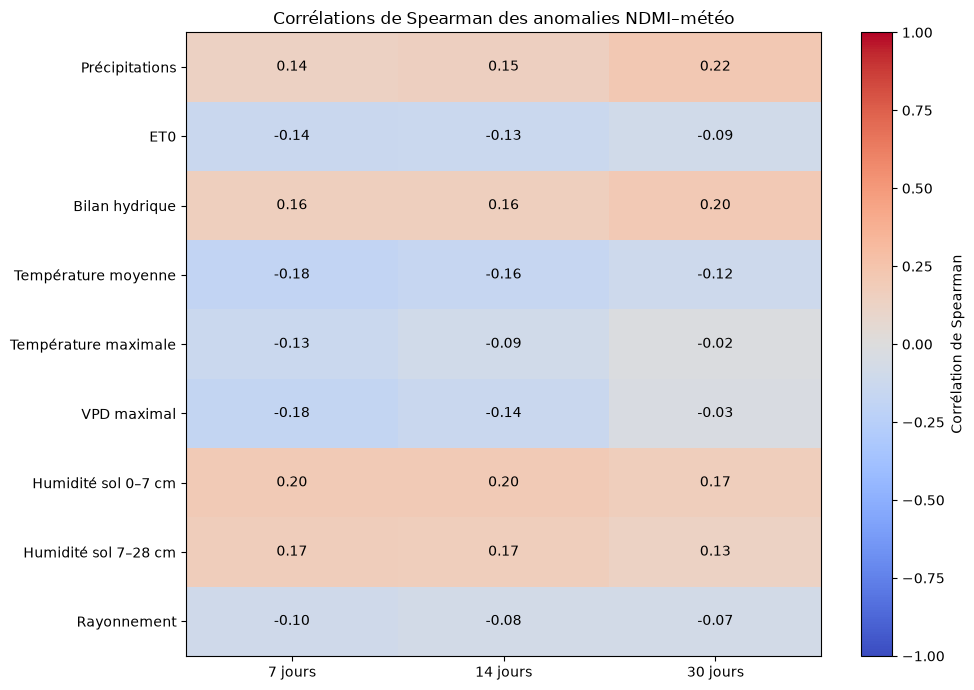

,7 jours,14 jours,30 jours
Précipitations,0.140,0.155,0.218
ET0,-0.140,-0.129,-0.088
Bilan hydrique,0.157,0.157,0.204
Température moyenne,-0.180,-0.158,-0.117
Température maximale,-0.130,-0.092,-0.018
VPD maximal,-0.179,-0.136,-0.034
Humidité sol 0–7 cm,0.198,0.199,0.171
Humidité sol 7–28 cm,0.175,0.168,0.132
Rayonnement,-0.097,-0.077,-0.075


In [9]:
WINDOW_FEATURES = {
    "Précipitations": {
        7: "precipitation_7d",
        14: "precipitation_14d",
        30: "precipitation_30d",
    },
    "ET0": {7: "et0_7d", 14: "et0_14d", 30: "et0_30d"},
    "Bilan hydrique": {
        7: "water_balance_7d",
        14: "water_balance_14d",
        30: "water_balance_30d",
    },
    "Température moyenne": {
        7: "temperature_mean_7d",
        14: "temperature_mean_14d",
        30: "temperature_mean_30d",
    },
    "Température maximale": {
        7: "temperature_max_7d",
        14: "temperature_max_14d",
        30: "temperature_max_30d",
    },
    "VPD maximal": {
        7: "vpd_max_7d",
        14: "vpd_max_14d",
        30: "vpd_max_30d",
    },
    "Humidité sol 0–7 cm": {
        7: "soil_moisture_0_7cm_mean_7d",
        14: "soil_moisture_0_7cm_mean_14d",
        30: "soil_moisture_0_7cm_mean_30d",
    },
    "Humidité sol 7–28 cm": {
        7: "soil_moisture_7_28cm_mean_7d",
        14: "soil_moisture_7_28cm_mean_14d",
        30: "soil_moisture_7_28cm_mean_30d",
    },
    "Rayonnement": {
        7: "radiation_sum_7d",
        14: "radiation_sum_14d",
        30: "radiation_sum_30d",
    },
}

window_table = pd.DataFrame(
    index=WINDOW_FEATURES.keys(),
    columns=["7 jours", "14 jours", "30 jours"],
    dtype=float,
)

for driver, window_mapping in WINDOW_FEATURES.items():
    for window, feature in window_mapping.items():
        window_table.loc[driver, f"{window} jours"] = (
            spearman_correlation(
                growing_anomaly[anomaly_target],
                growing_anomaly[f"{feature}_anomaly"],
            )
        )

fig, axis = plt.subplots(figsize=(10, 7))
image = axis.imshow(
    window_table.to_numpy(dtype=float),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

axis.set_xticks(range(len(window_table.columns)), window_table.columns)
axis.set_yticks(range(len(window_table.index)), window_table.index)
axis.set_title("Corrélations de Spearman des anomalies NDMI–météo")

for row in range(len(window_table.index)):
    for column in range(len(window_table.columns)):
        value = window_table.iloc[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black" if abs(value) < 0.55 else "white",
        )

fig.colorbar(image, ax=axis, label="Corrélation de Spearman")
plt.tight_layout()
plt.show()

display(window_table.round(3))

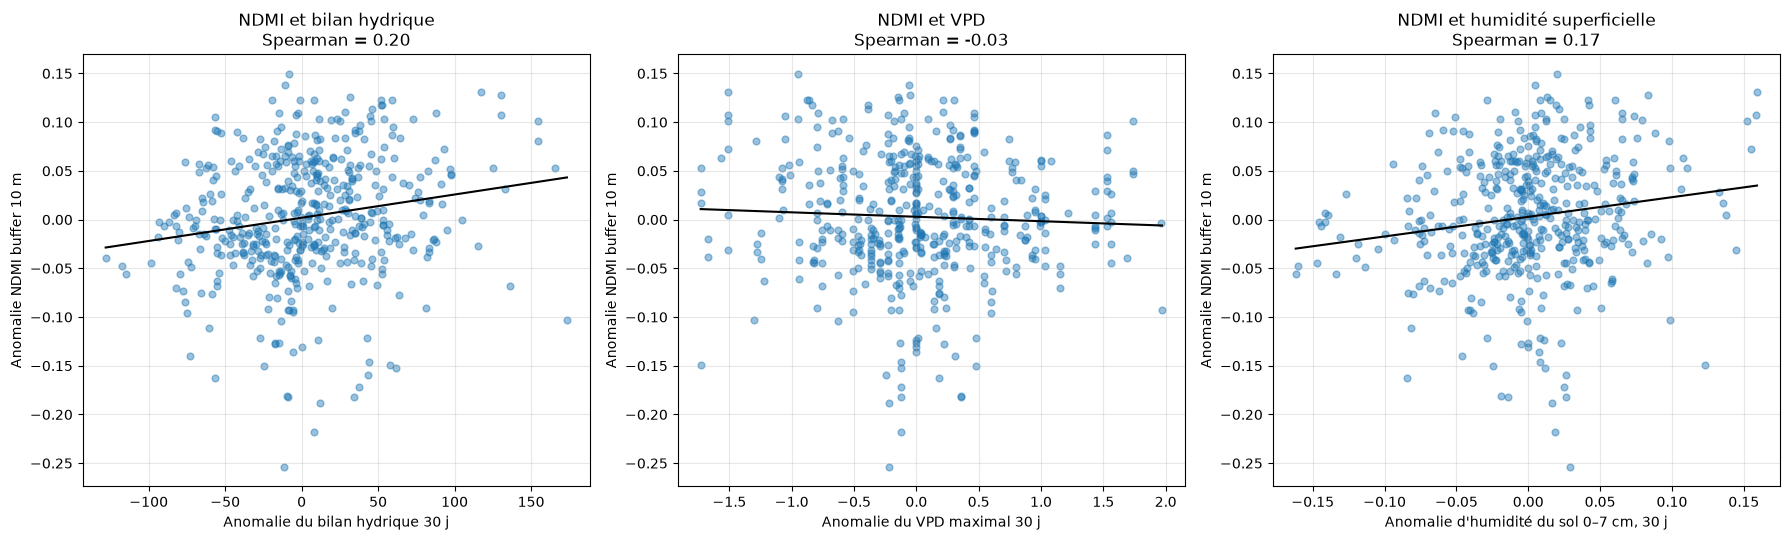

In [10]:
def scatter_with_trend(
    axis,
    dataframe: pd.DataFrame,
    x_column: str,
    y_column: str,
    title: str,
    x_label: str,
) -> None:
    paired = dataframe[[x_column, y_column]].dropna()

    axis.scatter(
        paired[x_column],
        paired[y_column],
        alpha=0.45,
        s=24,
    )

    if paired[x_column].nunique() > 1:
        slope, intercept = np.polyfit(
            paired[x_column],
            paired[y_column],
            1,
        )
        x_line = np.linspace(
            paired[x_column].min(),
            paired[x_column].max(),
            100,
        )
        axis.plot(x_line, slope * x_line + intercept, color="black")

    spearman = spearman_correlation(
        paired[x_column],
        paired[y_column],
    )
    axis.set_title(f"{title}\nSpearman = {spearman:.2f}")
    axis.set_xlabel(x_label)
    axis.set_ylabel("Anomalie NDMI buffer 10 m")
    axis.grid(alpha=0.3)


scatter_features = [
    (
        "water_balance_30d_anomaly",
        "NDMI et bilan hydrique",
        "Anomalie du bilan hydrique 30 j",
    ),
    (
        "vpd_max_30d_anomaly",
        "NDMI et VPD",
        "Anomalie du VPD maximal 30 j",
    ),
    (
        "soil_moisture_0_7cm_mean_30d_anomaly",
        "NDMI et humidité superficielle",
        "Anomalie d'humidité du sol 0–7 cm, 30 j",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for axis, (x_column, title, x_label) in zip(axes, scatter_features):
    scatter_with_trend(
        axis,
        growing_anomaly,
        x_column,
        anomaly_target,
        title,
        x_label,
    )

plt.tight_layout()
plt.show()

## 7. NDMI brut ou NDMI bufferisé à 10 m ?

La comparaison utilise strictement les mêmes dates et les mêmes variables météo. On compare les corrélations des anomalies, sans interpréter une différence de corrélation comme une preuve que la météo explique causalement un indice. Une association plus faible après retrait ne signifie pas que le buffer est moins fiable : il peut aussi supprimer un signal extérieur corrélé ou réduire le nombre de pixels.

In [11]:
common_df = df_weather.loc[raw_buffer_common_mask].copy()
common_df["month"] = common_df["acquisition_date"].dt.month

common_anomaly = add_monthly_anomalies(
    common_df,
    ["ndmi_mean", "ndmi_buffer_10m_mean", *WEATHER_FEATURES],
)

common_growing = common_anomaly.loc[
    common_anomaly["month"].between(4, 10)
].copy()

common_anomaly_features = [
    f"{column}_anomaly" for column in WEATHER_FEATURES
]

raw_profile = correlation_table(
    common_growing,
    "ndmi_mean_anomaly",
    common_anomaly_features,
)[["spearman"]].rename(columns={"spearman": "raw_spearman"})

buffer_profile = correlation_table(
    common_growing,
    "ndmi_buffer_10m_mean_anomaly",
    common_anomaly_features,
)[["spearman"]].rename(columns={"spearman": "buffer_spearman"})

raw_buffer_comparison = raw_profile.join(buffer_profile)
raw_buffer_comparison.index = [
    column.removesuffix("_anomaly")
    for column in raw_buffer_comparison.index
]
raw_buffer_comparison["delta_abs"] = (
    raw_buffer_comparison["buffer_spearman"].abs()
    - raw_buffer_comparison["raw_spearman"].abs()
)
raw_buffer_comparison = raw_buffer_comparison.sort_values(
    "delta_abs",
    ascending=False,
)

raw_buffer_same_date_correlation = common_df[
    ["ndmi_mean", "ndmi_buffer_10m_mean"]
].corr().iloc[0, 1]

buffer_gain_summary = pd.Series(
    {
        "dates_communes": len(common_df),
        "correlation_brut_buffer": raw_buffer_same_date_correlation,
        "moyenne_abs_spearman_brut": raw_buffer_comparison[
            "raw_spearman"
        ].abs().mean(),
        "moyenne_abs_spearman_buffer": raw_buffer_comparison[
            "buffer_spearman"
        ].abs().mean(),
    },
    name="valeur",
)

display(buffer_gain_summary.to_frame().round(3))
display(raw_buffer_comparison.round(3))

,valeur
dates_communes,676.000
correlation_brut_buffer,0.993
moyenne_abs_spearman_brut,0.190
moyenne_abs_spearman_buffer,0.139


,raw_spearman,buffer_spearman,delta_abs
precipitation_14d,0.194,0.154,-0.039
radiation_sum_7d,-0.137,-0.097,-0.040
precipitation_7d,0.180,0.139,-0.041
precipitation_30d,0.264,0.221,-0.043
radiation_sum_14d,-0.122,-0.077,-0.045
radiation_sum_30d,-0.123,-0.076,-0.047
temperature_max_14d,-0.141,-0.093,-0.048
temperature_mean_30d,-0.167,-0.118,-0.048
water_balance_14d,0.205,0.157,-0.048
water_balance_7d,0.206,0.157,-0.049


## 8. Comparaison secondaire des quatre indices

Cette section vérifie si NDVI, EVI et NDRE racontent une histoire météo compatible avec le NDMI. Elle ne répète pas toute l’analyse pour chaque indice.

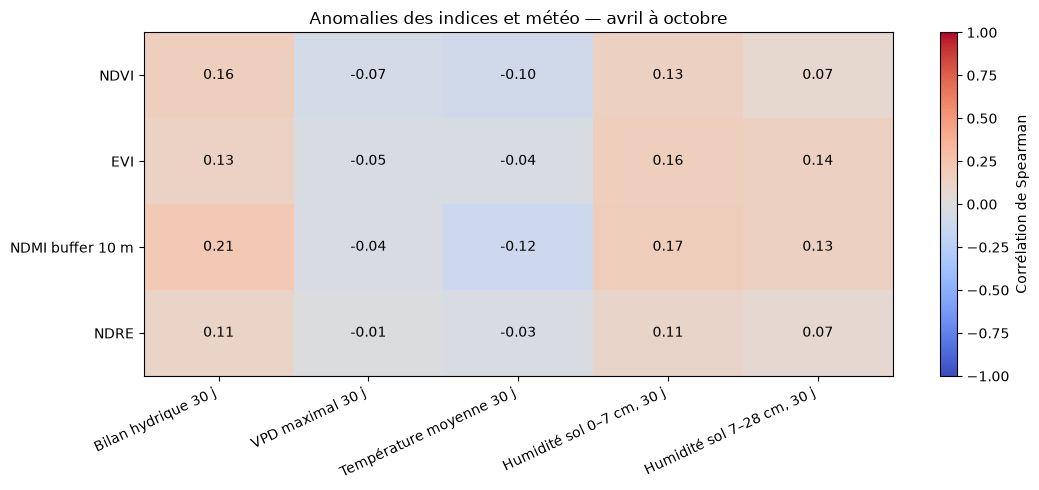

,Bilan hydrique 30 j,VPD maximal 30 j,Température moyenne 30 j,"Humidité sol 0–7 cm, 30 j","Humidité sol 7–28 cm, 30 j"
NDVI,0.159,-0.069,-0.098,0.134,0.072
EVI,0.129,-0.046,-0.044,0.158,0.136
NDMI buffer 10 m,0.206,-0.035,-0.118,0.173,0.134
NDRE,0.113,-0.010,-0.033,0.109,0.068


In [12]:
INDEX_COLUMNS = {
    "NDVI": "ndvi_mean",
    "EVI": "evi_mean",
    "NDMI buffer 10 m": "ndmi_buffer_10m_mean",
    "NDRE": "ndre_mean",
}

COMPARISON_WEATHER_COLUMNS = {
    "Bilan hydrique 30 j": "water_balance_30d",
    "VPD maximal 30 j": "vpd_max_30d",
    "Température moyenne 30 j": "temperature_mean_30d",
    "Humidité sol 0–7 cm, 30 j": "soil_moisture_0_7cm_mean_30d",
    "Humidité sol 7–28 cm, 30 j": "soil_moisture_7_28cm_mean_30d",
}

multi_anomaly = add_monthly_anomalies(
    all_indices_df,
    [*INDEX_COLUMNS.values(), *COMPARISON_WEATHER_COLUMNS.values()],
)

multi_growing = multi_anomaly.loc[
    multi_anomaly["month"].between(4, 10)
].copy()

multi_index_correlations = pd.DataFrame(
    index=INDEX_COLUMNS.keys(),
    columns=COMPARISON_WEATHER_COLUMNS.keys(),
    dtype=float,
)

for index_label, index_column in INDEX_COLUMNS.items():
    for weather_label, weather_column in COMPARISON_WEATHER_COLUMNS.items():
        multi_index_correlations.loc[index_label, weather_label] = (
            spearman_correlation(
                multi_growing[f"{index_column}_anomaly"],
                multi_growing[f"{weather_column}_anomaly"],
            )
        )

fig, axis = plt.subplots(figsize=(11, 5))
image = axis.imshow(
    multi_index_correlations.to_numpy(dtype=float),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

axis.set_xticks(
    range(len(multi_index_correlations.columns)),
    multi_index_correlations.columns,
    rotation=25,
    ha="right",
)
axis.set_yticks(
    range(len(multi_index_correlations.index)),
    multi_index_correlations.index,
)
axis.set_title("Anomalies des indices et météo — avril à octobre")

for row in range(len(multi_index_correlations.index)):
    for column in range(len(multi_index_correlations.columns)):
        value = multi_index_correlations.iloc[row, column]
        axis.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="black" if abs(value) < 0.55 else "white",
        )

fig.colorbar(image, ax=axis, label="Corrélation de Spearman")
plt.tight_layout()
plt.show()

display(multi_index_correlations.round(3))

## 9. Contexte annuel 2016–2025

Les statistiques météo annuelles sont calculées sur tous les jours d’avril à octobre, et non seulement sur les dates Sentinel. Les années 2015 et 2026 sont exclues du classement parce qu’elles sont incomplètes.

In [13]:
df_daily["year"] = df_daily["date"].dt.year
df_daily["month"] = df_daily["date"].dt.month

daily_growing = df_daily.loc[
    df_daily["month"].between(4, 10)
    & df_daily["year"].between(2016, 2025)
].copy()

daily_growing["daily_water_balance"] = (
    daily_growing["precipitation_sum"]
    - daily_growing["et0_fao_evapotranspiration"]
)
daily_growing["hot_day_30c"] = (
    daily_growing["temperature_2m_max"] >= 30
).astype(int)

annual_weather = (
    daily_growing.groupby("year")
    .agg(
        weather_days=("date", "size"),
        precipitation_total=("precipitation_sum", "sum"),
        et0_total=("et0_fao_evapotranspiration", "sum"),
        water_balance_total=("daily_water_balance", "sum"),
        temperature_mean=("temperature_2m_mean", "mean"),
        hot_days_30c=("hot_day_30c", "sum"),
        vpd_median=("vapour_pressure_deficit_max", "median"),
        vpd_p90=(
            "vapour_pressure_deficit_max",
            lambda values: values.quantile(0.90),
        ),
        soil_moisture_0_7cm_mean=(
            "soil_moisture_0_to_7cm_mean",
            "mean",
        ),
        soil_moisture_7_28cm_mean=(
            "soil_moisture_7_to_28cm_mean",
            "mean",
        ),
    )
)

annual_vegetation = (
    multi_growing.assign(
        year=multi_growing["acquisition_date"].dt.year
    )
    .loc[lambda frame: frame["year"].between(2016, 2025)]
    .groupby("year")
    .agg(
        satellite_observations=("ndmi_buffer_10m_mean", "count"),
        ndvi_median=("ndvi_mean", "median"),
        evi_median=("evi_mean", "median"),
        ndmi_buffer_median=("ndmi_buffer_10m_mean", "median"),
        ndre_median=("ndre_mean", "median"),
    )
)

annual_context = annual_vegetation.join(annual_weather, how="inner")

display(annual_context.round(3))

,satellite_observations,ndvi_median,evi_median,ndmi_buffer_median,ndre_median,weather_days,precipitation_total,et0_total,water_balance_total,temperature_mean,hot_days_30c,vpd_median,vpd_p90,soil_moisture_0_7cm_mean,soil_moisture_7_28cm_mean
year,,,,,,,,,,,,,,,
2016,22,0.807,0.618,0.285,0.542,214,536.1,721.20,-185.10,16.200,17,1.095,2.588,0.304,0.308
2017,45,0.775,0.567,0.218,0.516,214,354.7,845.14,-490.44,17.570,39,1.615,3.191,0.236,0.228
2018,46,0.775,0.554,0.235,0.537,214,445.7,838.85,-393.15,18.387,25,1.520,2.998,0.253,0.254
2019,51,0.777,0.606,0.294,0.553,214,561.2,826.21,-265.01,17.581,32,1.480,3.032,0.272,0.276
2020,44,0.759,0.557,0.232,0.535,214,538.5,799.75,-261.25,17.297,19,1.425,2.751,0.263,0.265
2021,42,0.771,0.591,0.282,0.542,214,692.2,683.44,8.76,15.626,4,1.080,1.821,0.316,0.324
2022,51,0.780,0.583,0.268,0.533,214,525.8,893.16,-367.36,18.717,40,1.570,3.622,0.259,0.261
2023,49,0.794,0.629,0.291,0.561,214,621.9,795.93,-174.03,18.083,30,1.400,2.979,0.284,0.286
2024,37,0.759,0.567,0.253,0.523,214,692.9,716.34,-23.44,16.971,20,1.040,2.327,0.319,0.322


## 10. Épisodes compatibles avec un stress hydrique

Une date candidate combine une anomalie NDMI faible, une anomalie de bilan hydrique faible et une anomalie de VPD élevée. Ce filtre sert à sélectionner des dates à inspecter ; il ne diagnostique pas à lui seul un stress hydrique.

In [14]:
ndmi_threshold = growing_anomaly[anomaly_target].quantile(0.20)
water_balance_threshold = growing_anomaly[
    "water_balance_30d_anomaly"
].quantile(0.25)
vpd_threshold = growing_anomaly["vpd_max_30d_anomaly"].quantile(0.75)

stress_candidates = growing_anomaly.loc[
    (growing_anomaly[anomaly_target] <= ndmi_threshold)
    & (
        growing_anomaly["water_balance_30d_anomaly"]
        <= water_balance_threshold
    )
    & (growing_anomaly["vpd_max_30d_anomaly"] >= vpd_threshold)
].copy()

stress_columns = [
    "acquisition_date",
    "ndmi_buffer_10m_mean",
    "ndmi_buffer_10m_mean_anomaly",
    "water_balance_30d",
    "water_balance_30d_anomaly",
    "vpd_max_30d",
    "vpd_max_30d_anomaly",
    "soil_moisture_0_7cm_mean_30d",
    "soil_moisture_0_7cm_mean_30d_anomaly",
]

stress_display = (
    stress_candidates[stress_columns]
    .sort_values("acquisition_date")
    .copy()
)
stress_numeric_columns = stress_display.select_dtypes(
    include="number"
).columns
stress_display[stress_numeric_columns] = stress_display[
    stress_numeric_columns
].round(3)

print("Nombre de dates candidates :", len(stress_candidates))
display(stress_display)

Nombre de dates candidates : 12


,acquisition_date,ndmi_buffer_10m_mean,ndmi_buffer_10m_mean_anomaly,water_balance_30d,water_balance_30d_anomaly,vpd_max_30d,vpd_max_30d_anomaly,soil_moisture_0_7cm_mean_30d,soil_moisture_0_7cm_mean_30d_anomaly
321,2018-10-02,0.160,-0.048,-99.18,-117.175,3.27,1.15,0.145,-0.160
322,2018-10-05,0.152,-0.056,-96.71,-114.705,3.27,1.15,0.143,-0.162
325,2018-10-12,0.152,-0.055,-61.50,-79.495,2.92,0.80,0.172,-0.134
327,2018-10-17,0.159,-0.049,-54.01,-72.005,2.92,0.80,0.191,-0.114
588,2020-07-31,0.224,-0.049,-134.03,-27.130,4.29,0.43,0.189,-0.043
847,2022-05-17,0.250,-0.074,-73.38,-77.770,2.40,0.61,0.276,-0.062
848,2022-05-19,0.254,-0.070,-77.60,-81.990,2.94,1.15,0.270,-0.068
861,2022-06-21,0.274,-0.045,-144.59,-98.210,4.15,1.56,0.168,-0.147
880,2022-08-07,0.172,-0.085,-181.63,-75.985,4.89,0.60,0.156,-0.033
881,2022-08-10,0.161,-0.096,-180.52,-74.875,4.89,0.60,0.151,-0.039


## 11. Synthèse des résultats à interpréter

Les tableaux suivants rassemblent les associations saisonnières les plus fortes, les fenêtres météo les plus informatives et les dates candidates. Ils constituent la base de la conclusion, sans transformer une corrélation en relation causale.

In [15]:
strongest_windows = (
    window_table.stack()
    .rename("spearman")
    .to_frame()
)
strongest_windows["abs_spearman"] = strongest_windows["spearman"].abs()
strongest_windows = strongest_windows.sort_values(
    "abs_spearman",
    ascending=False,
)

print("Principales associations des anomalies NDMI–météo")
display(anomaly_correlations.head(10).round(3))

print("Fenêtres météo les plus fortement associées au NDMI")
display(strongest_windows.head(10).round(3))

print("Comparaison NDMI brut / buffer 10 m")
display(buffer_gain_summary.to_frame().round(3))

strongest_positive = anomaly_correlations.sort_values(
    "spearman",
    ascending=False,
).iloc[0]
strongest_positive_name = anomaly_correlations["spearman"].idxmax()
strongest_negative = anomaly_correlations.sort_values(
    "spearman",
    ascending=True,
).iloc[0]
strongest_negative_name = anomaly_correlations["spearman"].idxmin()

buffer_mean_association = buffer_gain_summary[
    "moyenne_abs_spearman_buffer"
]
raw_mean_association = buffer_gain_summary[
    "moyenne_abs_spearman_brut"
]
buffer_comparison_text = (
    "plus forte"
    if buffer_mean_association > raw_mean_association
    else "plus faible"
)

candidate_years = (
    stress_candidates["acquisition_date"]
    .dt.year
    .value_counts()
    .sort_index()
    .to_dict()
)

print()
print("Lecture descriptive automatique")
print(
    "- Association positive la plus forte : "
    f"{strongest_positive_name} "
    f"(Spearman={strongest_positive['spearman']:.3f})."
)
print(
    "- Association négative la plus forte : "
    f"{strongest_negative_name} "
    f"(Spearman={strongest_negative['spearman']:.3f})."
)
print(
    "- Association météo moyenne du NDMI bufferisé : "
    f"{buffer_comparison_text} que celle du NDMI brut "
    "sur les mêmes dates."
)
print("- Dates candidates par année :", candidate_years)
print(
    "- Ces résultats quantifient des associations et non des causes."
)

Principales associations des anomalies NDMI–météo


,n,pearson,spearman,abs_spearman
precipitation_30d,476,0.185,0.218,0.218
water_balance_30d,476,0.180,0.204,0.204
soil_moisture_0_7cm_mean_14d,476,0.181,0.199,0.199
soil_moisture_0_7cm_mean_7d,476,0.192,0.198,0.198
temperature_mean_7d,476,-0.151,-0.180,0.180
vpd_max_7d,476,-0.147,-0.179,0.179
soil_moisture_7_28cm_mean_7d,476,0.184,0.175,0.175
soil_moisture_0_7cm_mean_30d,476,0.162,0.171,0.171
soil_moisture_7_28cm_mean_14d,476,0.170,0.168,0.168
temperature_mean_14d,476,-0.131,-0.158,0.158


Fenêtres météo les plus fortement associées au NDMI


spearman  abs_spearman
Précipitations       30 jours     0.218         0.218
Bilan hydrique       30 jours     0.204         0.204
Humidité sol 0–7 cm  14 jours     0.199         0.199
                     7 jours      0.198         0.198
Température moyenne  7 jours     -0.180         0.180
VPD maximal          7 jours     -0.179         0.179
Humidité sol 7–28 cm 7 jours      0.175         0.175
Humidité sol 0–7 cm  30 jours     0.171         0.171
Humidité sol 7–28 cm 14 jours     0.168         0.168
Température moyenne  14 jours    -0.158         0.158

Comparaison NDMI brut / buffer 10 m


,valeur
dates_communes,676.000
correlation_brut_buffer,0.993
moyenne_abs_spearman_brut,0.190
moyenne_abs_spearman_buffer,0.139



Lecture descriptive automatique
- Association positive la plus forte : precipitation_30d (Spearman=0.218).
- Association négative la plus forte : temperature_mean_7d (Spearman=-0.180).
- Association météo moyenne du NDMI bufferisé : plus faible que celle du NDMI brut sur les mêmes dates.
- Dates candidates par année : {2018: 4, 2020: 1, 2022: 6, 2026: 1}
- Ces résultats quantifient des associations et non des causes.


## Limites d’interprétation

- Les corrélations peuvent refléter des facteurs communs ou des mécanismes indirects.
- Les fenêtres de 7, 14 et 30 jours se terminent le jour de l’acquisition ; elles décrivent correctement la météo antérieure sans décaler les lignes Sentinel, dont l’espacement est irrégulier.
- ERA5 Seamless ne représente pas une station installée dans la parcelle.
- L’irrigation, la taille, l’enherbement, les maladies, la structure du sol et les autres pratiques culturales ne sont pas observés.
- Les années 2015 et 2026 sont partielles et ne doivent pas être classées avec 2016–2025.
- Les dates candidates doivent être vérifiées spatialement dans le notebook végétation et confrontées aux informations de terrain.